# AAX, Seminar 4: Wi-Fi Performance Prediction with Neural Networks

**Author:** Melker Svensson, Felipe Lopez, Raul 

## Problem statement

We revisit the Wi-Fi performance prediction problem from Seminar 1, but this time we will solve it with a Feedforward Neural Network (FNN) instead of a linear regression. The dataset contains Wi-Fi measurements taken from real residential networks during one month, split into `train_data.csv` and `test_data.csv`.

**Features**
* `LocationNumber`, zone where the measurement was taken (categorical, up to 35).
* `RSSI`, received signal strength.
* `TxLinkSpeed`, downlink link speed (AP to STA).
* `RxLinkSpeed`, uplink link speed (STA to AP).
* `MainAPConnect`, binary, 1 if connected to the main AP, 0 if connected to an extender.

**Targets (performance metrics)**
* `TxThroughput`, achieved throughput.
* `AvgPingLatency`, average ping latency to a server.

## Part I, Data preparation and analysis

In this first part we explore the dataset to understand its structure, the distribution of each feature, and the relationships between features and performance metrics. This insight will drive feature selection and preprocessing in Part II.

### 1. Imports and configuration

We use `pandas` for tabular handling, `numpy` for numerics, and `matplotlib` plus `seaborn` for visualisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

### 2. Load the dataset

We load the train and test CSV files. For exploration we mostly use the training set, the test set is kept untouched and only used in Part II for the final evaluation.

In [2]:
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test  shape: {test_df.shape}")
train_df.head()

Train shape: (33600, 7)
Test  shape: (8400, 7)


,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
0,2,-72.320,163.110,118.360,1,13.510,51.790
1,32,-73.180,238.450,212.830,1,3.350,68.800
2,20,-40.670,865.440,863.390,1,17.620,50.790
3,10,-60.660,473.890,396.920,1,14.300,64.150
4,29,-67.960,479.740,355.990,1,4.810,73.810


### 3. Basic structure and data quality

We check column types, missing values, and duplicates. Clean data is a prerequisite before fitting a neural network. NaNs or extreme outliers can destabilise training for neural setups.

In [6]:
# column types
train_df.dtypes

LocationNumber      int64
RSSI              float64
TxLinkSpeed       float64
RxLinkSpeed       float64
MainAPConnect       int64
TxThroughput      float64
AvgPingLatency    float64
dtype: object

In [7]:
# missing values per column
train_df.isna().sum()

LocationNumber    0
RSSI              0
TxLinkSpeed       0
RxLinkSpeed       0
MainAPConnect     0
TxThroughput      0
AvgPingLatency    0
dtype: int64

In [5]:
# duplicated rows
print(f"Duplicated rows in train: {train_df.duplicated().sum()}")
print(f"Duplicated rows in test : {test_df.duplicated().sum()}")

Duplicated rows in train: 0
Duplicated rows in test : 0


No NaNs, no duplicates and data types are alredy numeric. Great :) 

### 4. Descriptive statistics

`describe()` gives us mean, std, min, quartiles and max for every numeric column. This is the quickest way to spot suspicious ranges (e.g., negative throughput) and to get a feel for the scale of each feature, which matters later for normalisation.

In [8]:
train_df.describe()

,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
count,"33,600.000","33,600.000","33,600.000","33,600.000","33,600.000","33,600.000","33,600.000"
mean,18.151,-62.364,491.265,460.954,0.914,12.989,54.771
std,10.338,9.442,240.869,251.600,0.280,4.414,8.736
min,1.000,-79.040,33.240,-12.530,0.000,0.780,39.300
25%,9.000,-70.360,273.200,249.127,1.000,11.320,48.940
50%,18.000,-62.910,476.635,396.480,1.000,14.790,52.290
75%,27.000,-53.790,664.390,656.422,1.000,15.980,57.470
max,36.000,-37.020,905.390,911.000,1.000,19.160,96.550


### 5. Distribution of each feature and target

Histograms reveal the shape of each variable, useful to detect skew, multimodality or hard limits. For neural networks, very skewed inputs or targets often benefit from a log transform or robust scaling.

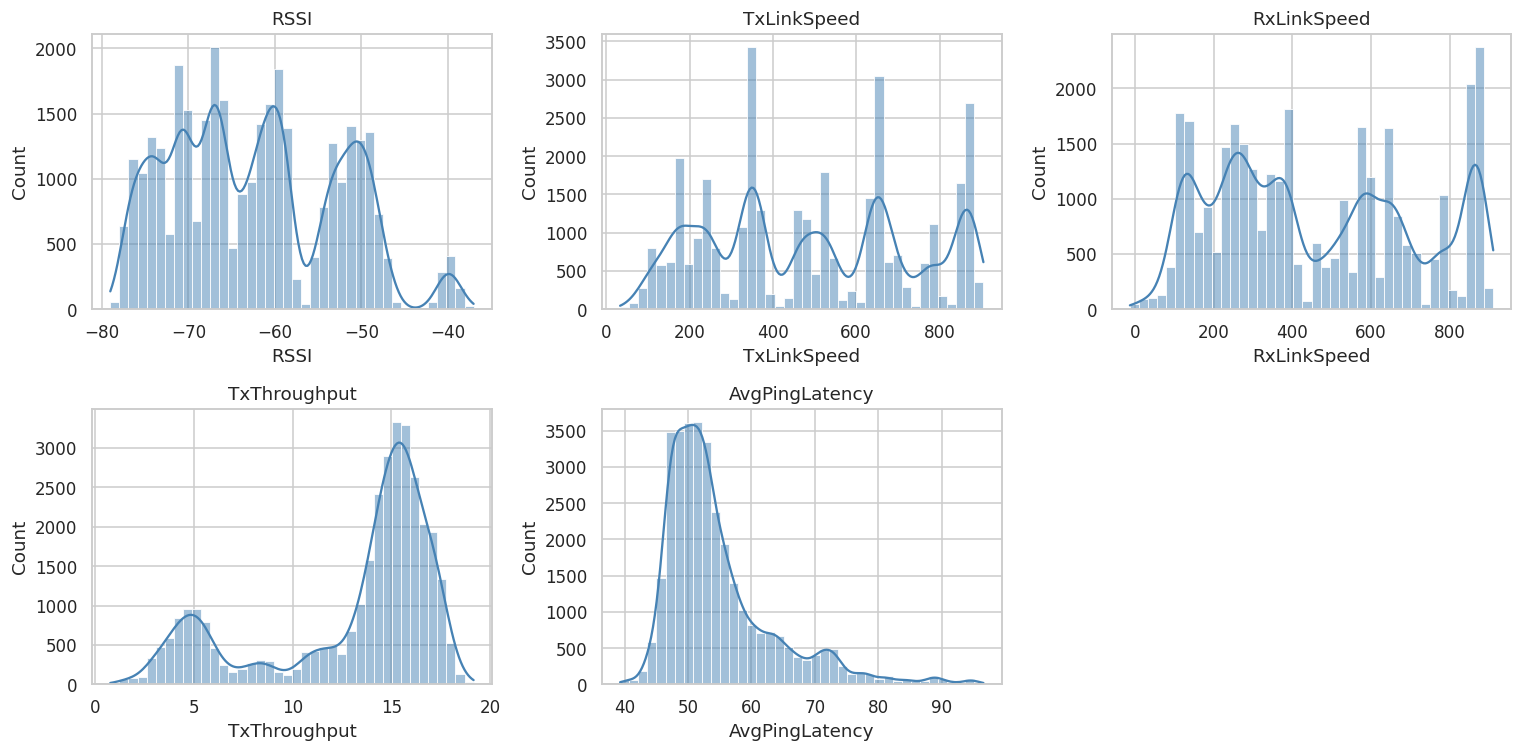

In [9]:
numeric_cols = ["RSSI", "TxLinkSpeed", "RxLinkSpeed", "TxThroughput", "AvgPingLatency"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(train_df[col], bins=40, kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

No skewed distributions, however Tx/RxLinkSpeed on the x-axis have big ranges and large values. They also don't seem to follow a very defined distribution, with relatively concentrated discrete values. 

### 6. Categorical and binary features

`LocationNumber` is categorical (zone id, up to 35) and `MainAPConnect` is binary. We look at their value counts to check class balance, an imbalanced binary feature, for example, would limit how informative it is for the model.

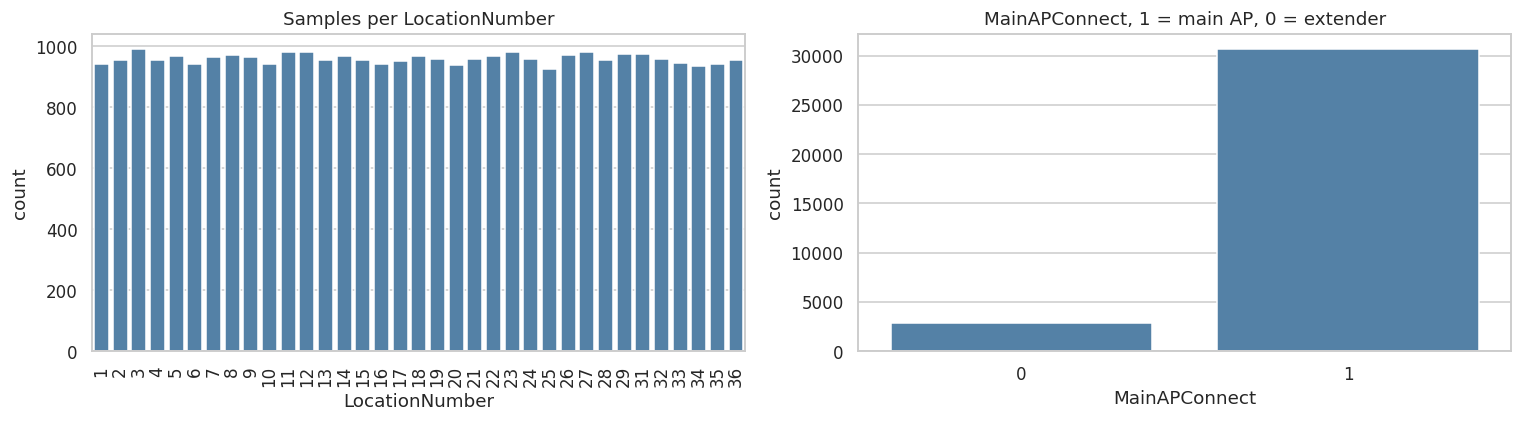

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(x="LocationNumber", data=train_df, ax=axes[0], color="steelblue")
axes[0].set_title("Samples per LocationNumber")
axes[0].tick_params(axis="x", rotation=90)

sns.countplot(x="MainAPConnect", data=train_df, ax=axes[1], color="steelblue")
axes[1].set_title("MainAPConnect, 1 = main AP, 0 = extender")

plt.tight_layout()
plt.show()

There is no class imbalance, all location numbers have roughly the same number of entries. However, MainAPConnect is very skewed, with far more points being connected to the AP (1) rather than the extender (0).

### 7. Boxplots, outlier check and effect of MainAPConnect

Boxplots highlight outliers in the numeric features. We also split the performance metrics by `MainAPConnect` to see whether being connected directly to the main AP changes throughput or latency, which is a strong prior in Wi-Fi networks.

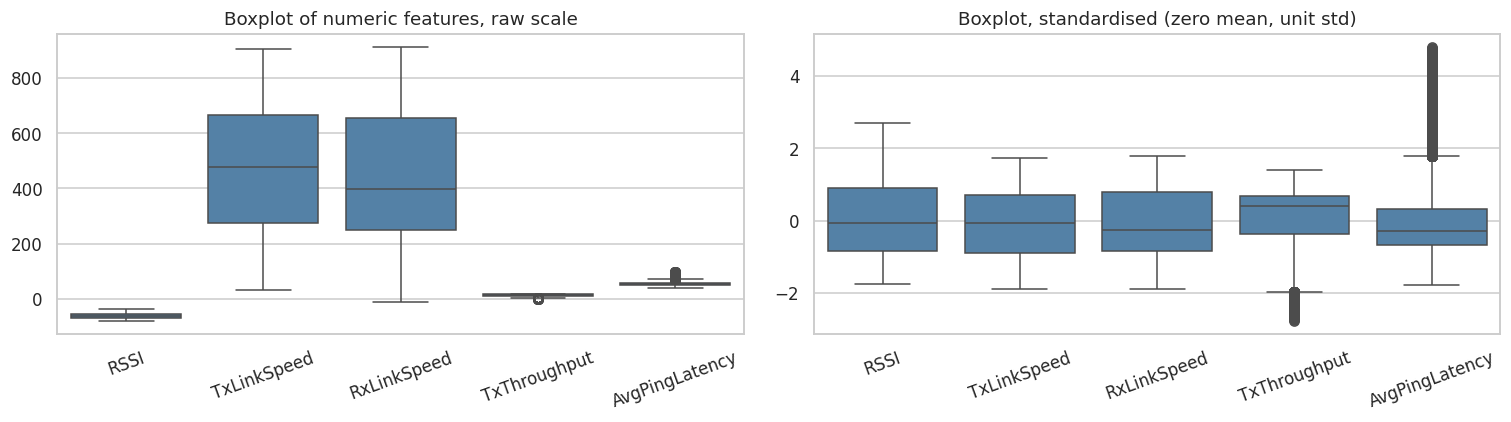

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=train_df[numeric_cols], ax=axes[0], color="steelblue")
axes[0].set_title("Boxplot of numeric features, raw scale")
axes[0].tick_params(axis="x", rotation=20)

# same boxplot, but standardised so all variables are visible together
standardised = (train_df[numeric_cols] - train_df[numeric_cols].mean()) / train_df[numeric_cols].std()
sns.boxplot(data=standardised, ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot, standardised (zero mean, unit std)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

Here we observe the same thing we noticed with the histograms. There are no direct outliers, and the xLinkSpeed are the features with more range. As expected, after standardization they all look quite similar.

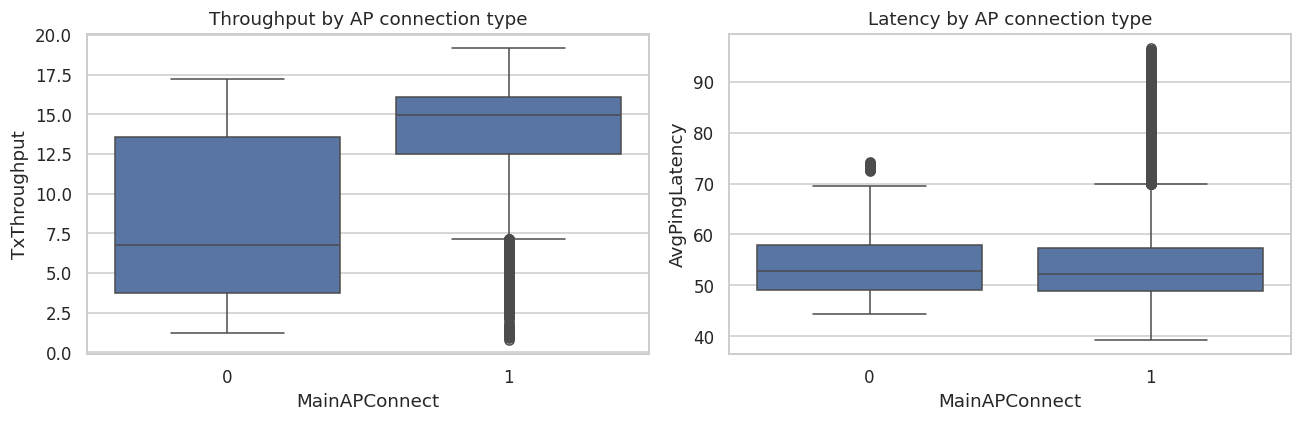

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="MainAPConnect", y="TxThroughput", data=train_df, ax=axes[0])
axes[0].set_title("Throughput by AP connection type")
sns.boxplot(x="MainAPConnect", y="AvgPingLatency", data=train_df, ax=axes[1])
axes[1].set_title("Latency by AP connection type")
plt.tight_layout()
plt.show()

Here we can easily see that being connected to the main AP (1) clearly affects positively the throughput, with devices connected to this on average having much better throughput and less range/variability in the boxplot.

However, being connected to AP (1) or Extender (0) does not affect Latency, which is similar in both.

### 8. Performance per location

We aggregate throughput and latency by `LocationNumber` to see whether the zone has a strong effect on performance. If the spread across zones is wide, `LocationNumber` will be a valuable categorical input for the FNN (one-hot encoded).

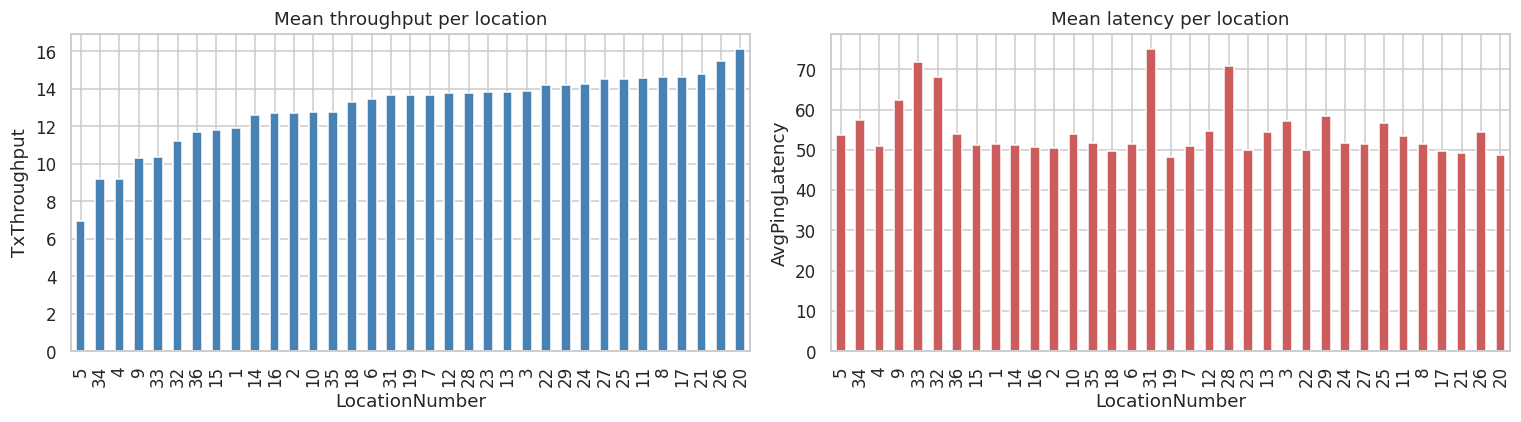

In [13]:
loc_stats = train_df.groupby("LocationNumber")[["TxThroughput", "AvgPingLatency"]].mean().sort_values("TxThroughput")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
loc_stats["TxThroughput"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Mean throughput per location")
axes[0].set_ylabel("TxThroughput")

loc_stats["AvgPingLatency"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Mean latency per location")
axes[1].set_ylabel("AvgPingLatency")
plt.tight_layout()
plt.show()

We can clearly see that LocationNumber is a strong indicator of performance on throughput, some locations on average have noticeably worse throughput than others. Such as 5 which on average has 6 while 20 has 16, a whole 10 point difference.

Meanwhile the LocationNumber, Latency relationship is less straightforward, with a lot of locations having similar values. However, there are also some outliers here.

### 9. Correlation analysis

We compute the Pearson correlation matrix between all numeric variables. Pearson captures linear relationships; we add Spearman afterwards to also catch monotonic non,linear ones, which is relevant because neural networks can exploit non,linear dependencies.

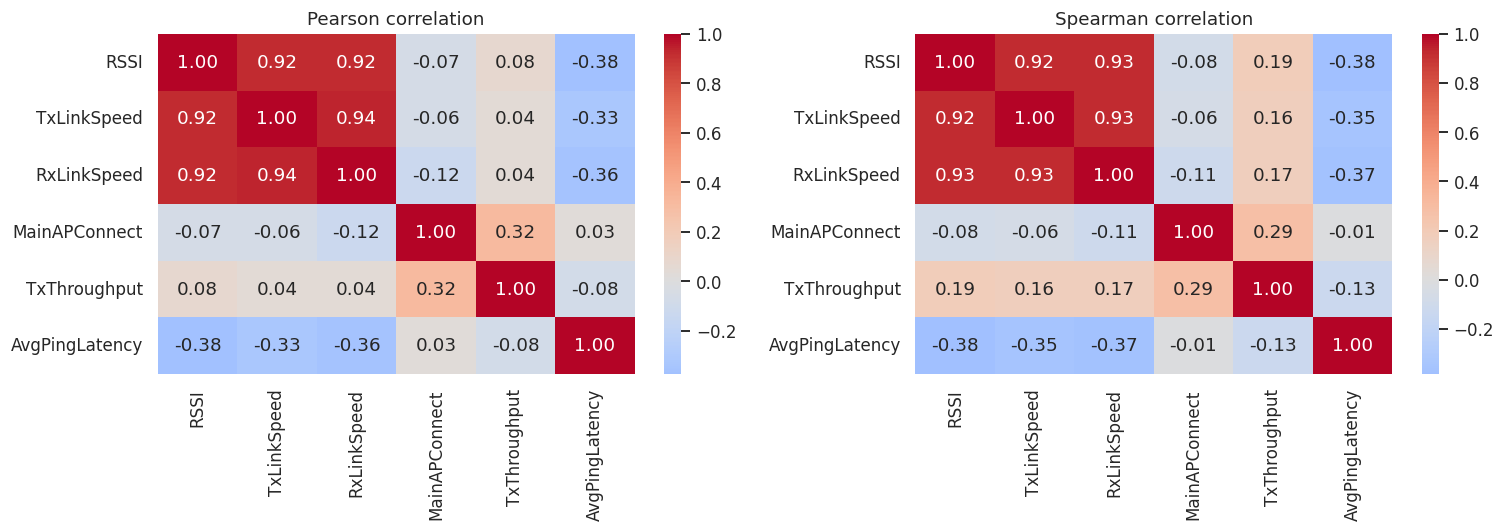

In [14]:
corr_cols = ["RSSI", "TxLinkSpeed", "RxLinkSpeed", "MainAPConnect", "TxThroughput", "AvgPingLatency"]

pearson_corr = train_df[corr_cols].corr(method="pearson")
spearman_corr = train_df[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Pearson correlation")
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman correlation")
plt.tight_layout()
plt.show()

Pearson and Spearman are very similar, indicating that the correlations we observe are essentially linear. For the two target labels we see the following:
- TxThroughput: correlates the highest with MainAPConnect (0.32)
- AvgPingLatency: correlates the highest with MainAPConnect (0.03)

In general these results show us that there is no strong correlation between features and target labels, indicating that the neural network is going to have to learn complex and non-trivial relationships between input feature space and outputs.

### 12. Summary of Part I

Key takeaways from the exploratory analysis:

* **Distributions**, no heavy skew on any variable, but `TxLinkSpeed` and `RxLinkSpeed` cover a very wide numeric range and look almost discrete (concentrated on a few values), while `RSSI` lives on a much smaller, negative scale.
* **Feature scales differ a lot**, link speeds are in the hundreds, RSSI is around ,60 dB, `MainAPConnect` is 0/1. Standardization will be required before training the FNN.
* **Class balance**, `LocationNumber` is well balanced across the 35 zones, but `MainAPConnect` is heavily skewed towards 1 (main AP), so the extender class will be under,represented during training.
* **Outliers**, the boxplots show no extreme outliers, the apparent spread of the link speeds comes from their natural range, not from anomalies.
* **Effect of MainAPConnect**, clients on the main AP (1) clearly achieve higher throughput and show less variability, but latency looks essentially the same on both AP and extender.
* **Effect of LocationNumber**, throughput depends strongly on the zone (some locations average around 6 while others reach 16), so the location is a meaningful categorical predictor and should be one-hot encoded. Its effect on latency is much weaker.
* **Correlations**, Pearson and Spearman agree, so the relationships captured are essentially linear and monotonic. The strongest correlation with `TxThroughput` is `MainAPConnect` (~0.32), and with `AvgPingLatency` it is also `MainAPConnect` (~0.03), but both are weak. 
* **Implication for modelling**, no single feature is strongly linearly correlated with the targets, especially for latency, so the FNN will need to capture non-trivial, non-linear interactions between inputs to predict performance. We may want to train separate models (or a multi-output one with weighted losses) so the easier throughput task does not dominate the harder latency one.

These findings will guide the feature selection, preprocessing and architecture design in Part II.

## Part II, FNN,based performance predictor

In this part we build a Feedforward Neural Network that predicts `TxThroughput` and `AvgPingLatency` jointly from the available features. We use a **multi,output FNN**, one shared trunk that learns a common representation and a final layer with two outputs. This is simpler than maintaining two networks and lets the model exploit features that are useful for both metrics.

### 13. Feature selection

We keep **all five features**, `LocationNumber`, `RSSI`, `TxLinkSpeed`, `RxLinkSpeed`, `MainAPConnect`. The feature space is small, so dropping `TxLinkSpeed` or `RxLinkSpeed` despite their similarity is not necessary, the FNN can learn to weigh them as needed. `LocationNumber` is treated as categorical (one-hot), the rest as numeric.

### 14. Data preparation

Three transformations are applied:

* **One-hot encoding** of `LocationNumber` (zone id), so the network does not treat it as ordinal.
* **Standardization** of the continuous features (`RSSI`, `TxLinkSpeed`, `RxLinkSpeed`) to zero mean and unit variance, fitted on train and applied to test.
* **Standardization of the targets** as well, this keeps the two outputs on comparable scales so the joint MSE loss does not get dominated by the metric with the larger range. We de,standardize at evaluation time to report metrics in the original units.

`MainAPConnect` is already 0/1 and is left as,is.

In [17]:
from sklearn.preprocessing import StandardScaler

CONT_FEATURES = ["RSSI", "TxLinkSpeed", "RxLinkSpeed"]
BIN_FEATURES = ["MainAPConnect"]
CAT_FEATURES = ["LocationNumber"]
TARGETS = ["TxThroughput", "AvgPingLatency"]

# one,hot encode LocationNumber, fit categories on the union so train/test align
all_locations = sorted(set(train_df["LocationNumber"]).union(test_df["LocationNumber"]))

def encode(df):
    loc_oh = pd.get_dummies(df["LocationNumber"], prefix="loc").reindex(
        columns=[f"loc_{l}" for l in all_locations], fill_value=0
    )
    return pd.concat([df[CONT_FEATURES + BIN_FEATURES].reset_index(drop=True),
                      loc_oh.reset_index(drop=True)], axis=1)

X_train_raw = encode(train_df)
X_test_raw = encode(test_df)
y_train_raw = train_df[TARGETS].values
y_test_raw = test_df[TARGETS].values

# standardize continuous features only, leave the binary + one,hot columns alone
feat_scaler = StandardScaler()
X_train = X_train_raw.copy().astype(float)
X_test = X_test_raw.copy().astype(float)
X_train[CONT_FEATURES] = feat_scaler.fit_transform(X_train[CONT_FEATURES])
X_test[CONT_FEATURES] = feat_scaler.transform(X_test[CONT_FEATURES])

# standardize targets
target_scaler = StandardScaler()
y_train = target_scaler.fit_transform(y_train_raw)
y_test = target_scaler.transform(y_test_raw)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")
X_train.head()

X_train shape: (33600, 39), X_test shape: (8400, 39)
y_train shape: (33600, 2), y_test shape: (8400, 2)


,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,loc_1,loc_2,loc_3,loc_4,loc_5,loc_6,...,loc_26,loc_27,loc_28,loc_29,loc_31,loc_32,loc_33,loc_34,loc_35,loc_36
0,-1.054,-1.362,-1.362,1.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,-1.145,-1.050,-0.986,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000
2,2.298,1.553,1.600,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.180,-0.072,-0.255,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,-0.593,-0.048,-0.417,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000


### 15. Baseline FNN architecture

Design choices:

* **Input layer**, one neuron per feature column after one-hot encoding (continuous + binary + one-hot zones).
* **Two hidden layers** of 64 and 32 units with **ReLU** activation. Two hidden layers are enough for a small tabular dataset, ReLU is the standard non,linearity, simple and well behaved with Adam.
* **Dropout** (rate 0.1) after each hidden layer for light regularization, helps mitigate overfitting given that some signals (latency) are weakly correlated with features.
* **Output layer**, 2 neurons with **linear activation**, one per regression target.
* **Loss**, Mean Squared Error (MSE), the natural loss for regression and well defined for multi,output when targets are standardized.
* **Optimizer**, Adam with the default learning rate of 1e,3, a safe default that adapts the step size per parameter.
* **Metrics tracked**, MAE for interpretability.

We also use **EarlyStopping** on validation loss to avoid overfitting and restore the best weights.

In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)
np.random.seed(42)

def build_model(n_features: int) -> tf.keras.Model:
    model = models.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(2, activation="linear"),  # [TxThroughput, AvgPingLatency]
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="mse",
                  metrics=["mae"])
    return model

model = build_model(X_train.shape[1])
model.summary()

### 16. Training

Training setup:

* **Batch size 64**, a balance between gradient noise and speed for ~33k samples.
* **Up to 200 epochs**, capped by EarlyStopping with patience 15 on validation loss.
* **Validation split 15%**, taken from the training set, gives the early stopping callback something to monitor without touching the test set.

In [ ]:
early_stop = callbacks.EarlyStopping(monitor="val_loss",
                                     patience=15,
                                     restore_best_weights=True)

history = model.fit(
    X_train.values, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=2,
)

### 17. Training curves

We plot the training and validation loss (MSE on standardized targets) and MAE per epoch. A widening gap between train and validation curves would indicate overfitting, parallel curves indicate a healthy fit.

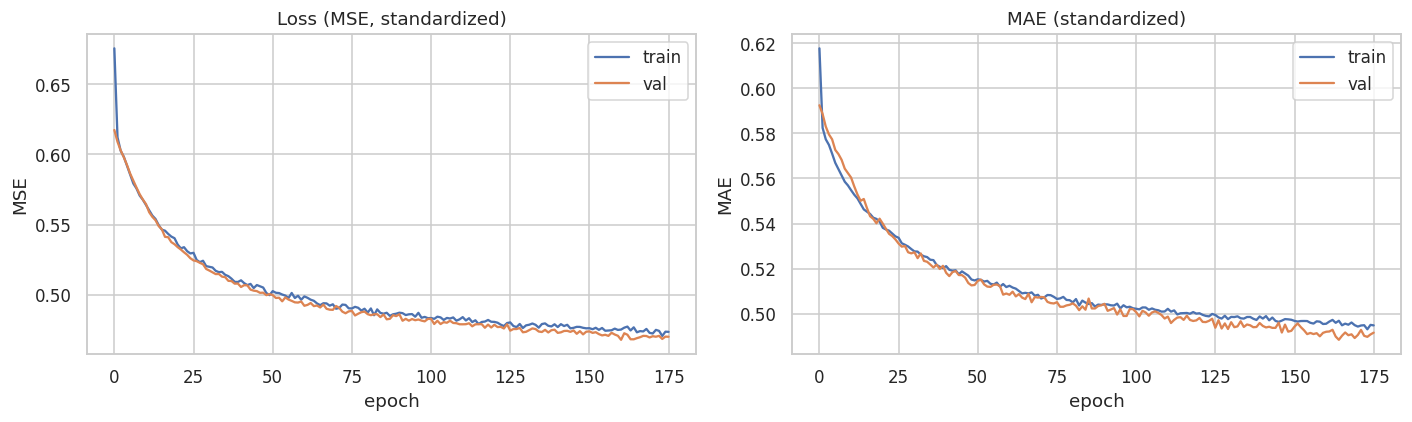

Best epoch (val_loss): 161
Final val_loss: 0.4678


,MAE,RMSE,R2
TxThroughput,2.557,3.450,0.395
AvgPingLatency,3.497,4.950,0.680


In [31]:
hist = history.history

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist["loss"], label="train")
axes[0].plot(hist["val_loss"], label="val")
axes[0].set_title("Loss (MSE, standardized)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE"); axes[0].legend()

axes[1].plot(hist["mae"], label="train")
axes[1].plot(hist["val_mae"], label="val")
axes[1].set_title("MAE (standardized)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("MAE"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Best epoch (val_loss): {int(np.argmin(hist['val_loss'])) + 1}")
print(f"Final val_loss: {min(hist['val_loss']):.4f}")

y_pred_std = model.predict(X_test.values, verbose=0)
y_pred = target_scaler.inverse_transform(y_pred_std)
y_true = y_test_raw

# Test set evaluation
metrics = {}
for i, name in enumerate(TARGETS):
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    metrics[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

pd.DataFrame(metrics).T

We see clear training graphs, with no indication of overfitting. The validation and training loss both decrease in pair following a nice shape. However, the combined loss of both target labels plateaus relatively quickly and the increase in performance stagnates. In fact the combined R² of the two is around 0.5, which is far from optimal 

### 18. Ablation 

The baseline shows signs of underfitting (R² ~0.4 on throughput), so we try four alternative architectures aimed at giving the model more capacity or changing its regularization. All variants share the same data, optimizer (Adam 1e,3), loss (MSE on standardized targets), batch size (64), validation split (0.15) and EarlyStopping (patience 15). Epochs are capped at **75**.

A small helper trains a model and plots its loss curves so the four blocks stay short and comparable.

In [25]:
EPOCHS_CAP = 75

def train_and_plot(model: tf.keras.Model, name: str):
    """Train the given compiled model and plot its loss/MAE curves. Reports test metrics."""
    es = callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    h = model.fit(X_train.values, y_train,
                  validation_split=0.15,
                  epochs=EPOCHS_CAP,
                  batch_size=64,
                  callbacks=[es],
                  verbose=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(h.history["loss"], label="train")
    axes[0].plot(h.history["val_loss"], label="val")
    axes[0].set_title(f"{name}, Loss (MSE std)"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(h.history["mae"], label="train")
    axes[1].plot(h.history["val_mae"], label="val")
    axes[1].set_title(f"{name}, MAE (std)"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

    y_pred = target_scaler.inverse_transform(model.predict(X_test.values, verbose=0))
    rows = {}
    for i, tname in enumerate(TARGETS):
        rows[tname] = {
            "MAE": mean_absolute_error(y_test_raw[:, i], y_pred[:, i]),
            "RMSE": np.sqrt(mean_squared_error(y_test_raw[:, i], y_pred[:, i])),
            "R2": r2_score(y_test_raw[:, i], y_pred[:, i]),
        }
    print(f"Best epoch: {int(np.argmin(h.history['val_loss'])) + 1}, "
          f"best val_loss: {min(h.history['val_loss']):.4f}")
    return pd.DataFrame(rows).T

#### Variant A, deeper network

**Architecture:** `128, 64, 32` ReLU layers, dropout 0.1 between them, linear 2,unit output.

**Motivation:** add one more hidden layer to let the network learn deeper feature interactions while keeping the same regularization as the baseline. A deeper but still modest network is the first cheap thing to try when underfitting.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,522 (60.63 KB)

 Trainable params: 15,522 (60.63 KB)

 Non-trainable params: 0 (0.00 B)

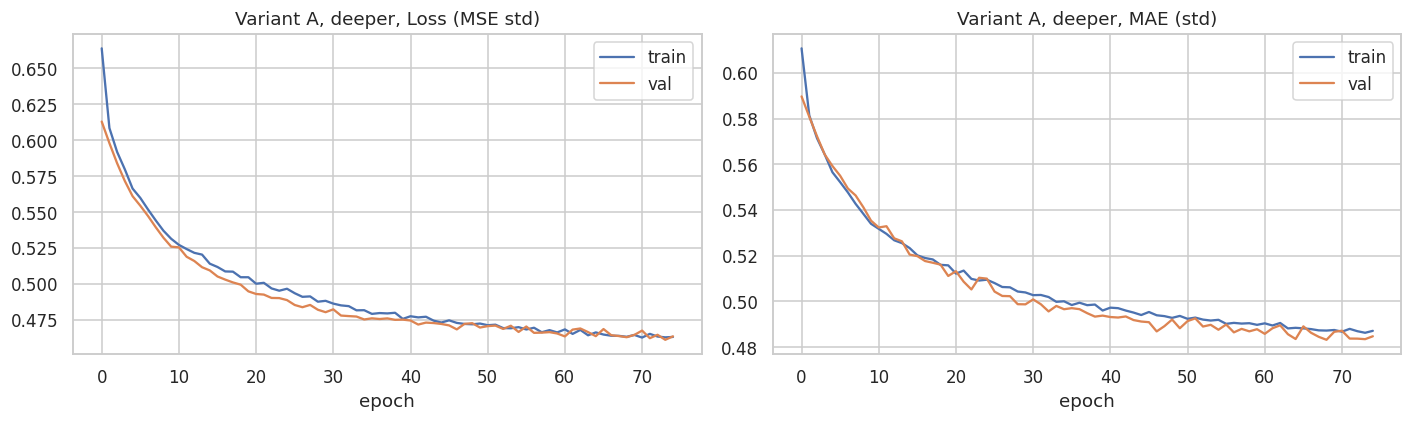

Best epoch: 74, best val_loss: 0.4611


,MAE,RMSE,R2
TxThroughput,2.516,3.419,0.406
AvgPingLatency,3.394,4.883,0.688


In [27]:
tf.random.set_seed(42); np.random.seed(42)

model_a = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"), layers.Dropout(0.1),
    layers.Dense(64,  activation="relu"), layers.Dropout(0.1),
    layers.Dense(32,  activation="relu"), layers.Dropout(0.1),
    layers.Dense(2,   activation="linear"),
])
model_a.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model_a.summary()

metrics_a = train_and_plot(model_a, "Variant A, deeper")
metrics_a

Very similar learning curves to the original, and very minimal difference in test metrics. The extra depth doesn't seem to help, but also doesn't hurt.

#### Variant B, wider network

**Architecture:** two large hidden layers `256, 128` ReLU, dropout 0.1, linear 2-unit output.

**Motivation:** instead of going deeper, increase the width of the hidden layers. Wider layers give the model more capacity per layer to combine input features, which is often what helps on small tabular problems.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,394 (169.51 KB)

 Trainable params: 43,394 (169.51 KB)

 Non-trainable params: 0 (0.00 B)

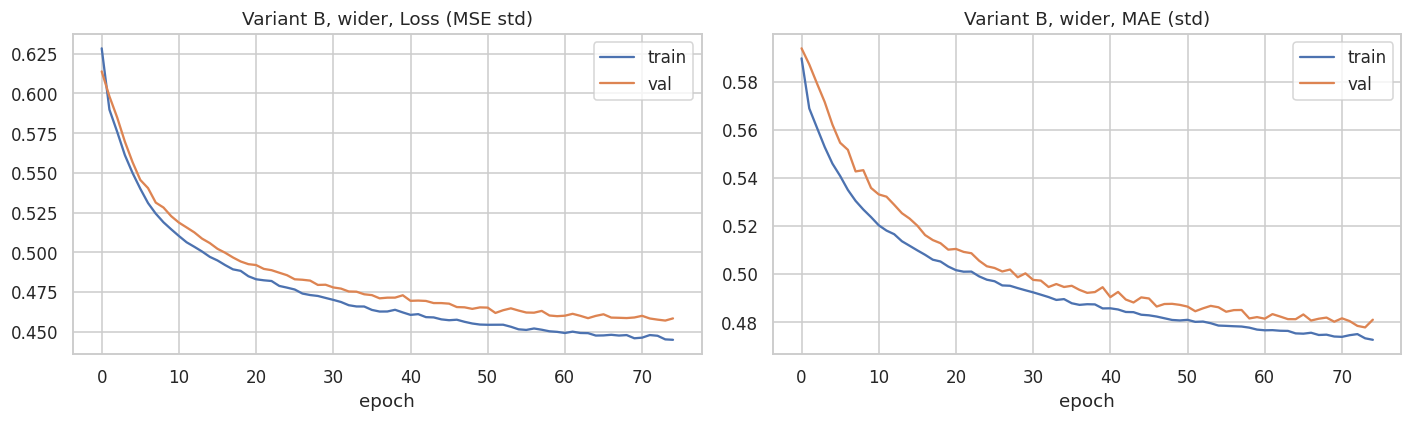

Best epoch: 74, best val_loss: 0.4571


,MAE,RMSE,R2
TxThroughput,2.487,3.401,0.412
AvgPingLatency,3.339,4.844,0.693


In [28]:
tf.random.set_seed(42); np.random.seed(42)

model_b = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation="relu"), layers.Dropout(0.1),
    layers.Dense(128, activation="relu"), layers.Dropout(0.1),
    layers.Dense(2,   activation="linear"),
])
model_b.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model_b.summary()

metrics_b = train_and_plot(model_b, "Variant B, wider")
metrics_b

Again very minimal improvements, and in fact we see more overfiting as the training and validation have bigger gaps.

#### Variant C, no dropout, higher learning rate

**Architecture:** `128, 64` ReLU layers, **no dropout**, linear 2,unit output, Adam at lr `5e,3`.

**Motivation:** if the model is underfitting, dropout might be hurting more than helping. Removing dropout and raising the learning rate lets the network fit the training data more aggressively. This is the classic underfitting test, if it overfits now we know capacity is not the problem.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,506 (52.76 KB)

 Trainable params: 13,506 (52.76 KB)

 Non-trainable params: 0 (0.00 B)

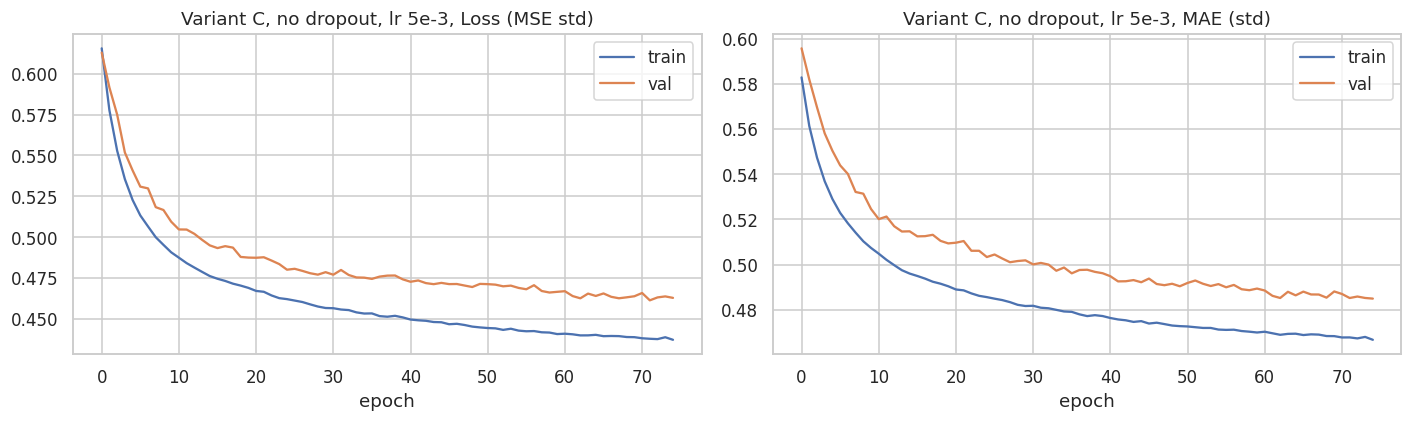

Best epoch: 72, best val_loss: 0.4613


,MAE,RMSE,R2
TxThroughput,2.534,3.429,0.403
AvgPingLatency,3.437,4.893,0.687


In [26]:
tf.random.set_seed(42); np.random.seed(42)

model_c = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64,  activation="relu"),
    layers.Dense(2,   activation="linear"),
])
model_c.compile(optimizer=tf.keras.optimizers.Adam(5e-3), loss="mse", metrics=["mae"])
model_c.summary()

metrics_c = train_and_plot(model_c, "Variant C, no dropout, lr 5e-3")
metrics_c

We definitely see indications of overfitting, the gap between validation and training curve is the largest seen. The model is clearly not generalizing as well as on other metrics. However, the final R² scores remain competitive with the other architectures, indicating that this one has still learned the same abstractions as the other ones.

#### Variant D, deep with BatchNorm

**Architecture:** `256, 128, 64, 32` ReLU layers, **BatchNormalization** after each dense layer, light dropout 0.05, linear 2,unit output.

**Motivation:** the largest model of the four. BatchNorm stabilizes the optimization of a deep network and acts as a mild regularizer, so we can afford less dropout. If even this model does not beat the baseline by much, we conclude the bottleneck is the information in the features, not model capacity.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,458 (216.63 KB)

 Trainable params: 54,498 (212.88 KB)

 Non-trainable params: 960 (3.75 KB)

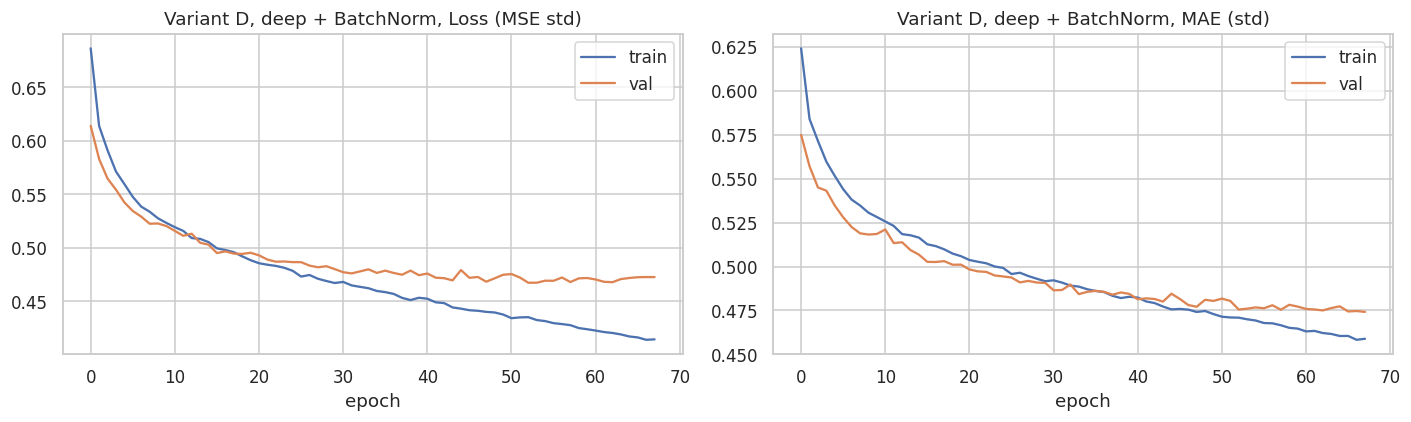

Best epoch: 53, best val_loss: 0.4672


,MAE,RMSE,R2
TxThroughput,2.455,3.447,0.396
AvgPingLatency,3.373,4.877,0.689


In [29]:
tf.random.set_seed(42); np.random.seed(42)

def dense_bn(units):
    return [layers.Dense(units), layers.BatchNormalization(), layers.Activation("relu"), layers.Dropout(0.05)]

model_d = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    *dense_bn(256),
    *dense_bn(128),
    *dense_bn(64),
    *dense_bn(32),
    layers.Dense(2, activation="linear"),
])
model_d.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model_d.summary()

metrics_d = train_and_plot(model_d, "Variant D, deep + BatchNorm")
metrics_d

After epoch 50 the model stats overfiting on the training set and the validation set plateaus. We see no improvement with respect to the final R2 scores.

### 20. Side-by-side comparison

We collect the test metrics of all five models (baseline + four variants) for a quick comparison.

In [30]:
baseline_metrics = pd.DataFrame(metrics).T  # from section 18
all_results = pd.concat({
    "Baseline (64,32)":     baseline_metrics,
    "A, deeper (128,64,32)": metrics_a,
    "B, wider (256,128)":    metrics_b,
    "C, no dropout":         metrics_c,
    "D, deep + BN":          metrics_d,
}, axis=0)
all_results

MAE  RMSE    R2
Baseline (64,32)      TxThroughput   2.557 3.450 0.395
                      AvgPingLatency 3.497 4.950 0.680
A, deeper (128,64,32) TxThroughput   2.516 3.419 0.406
                      AvgPingLatency 3.394 4.883 0.688
B, wider (256,128)    TxThroughput   2.487 3.401 0.412
                      AvgPingLatency 3.339 4.844 0.693
C, no dropout         TxThroughput   2.534 3.429 0.403
                      AvgPingLatency 3.437 4.893 0.687
D, deep + BN          TxThroughput   2.455 3.447 0.396
                      AvgPingLatency 3.373 4.877 0.689

### 21. Predicted vs actual of best model 

A scatter of predictions vs ground truth shows how well the model tracks each target, points should align along the diagonal. Residual histograms (prediction error distribution) should look centered around zero with no strong bias.

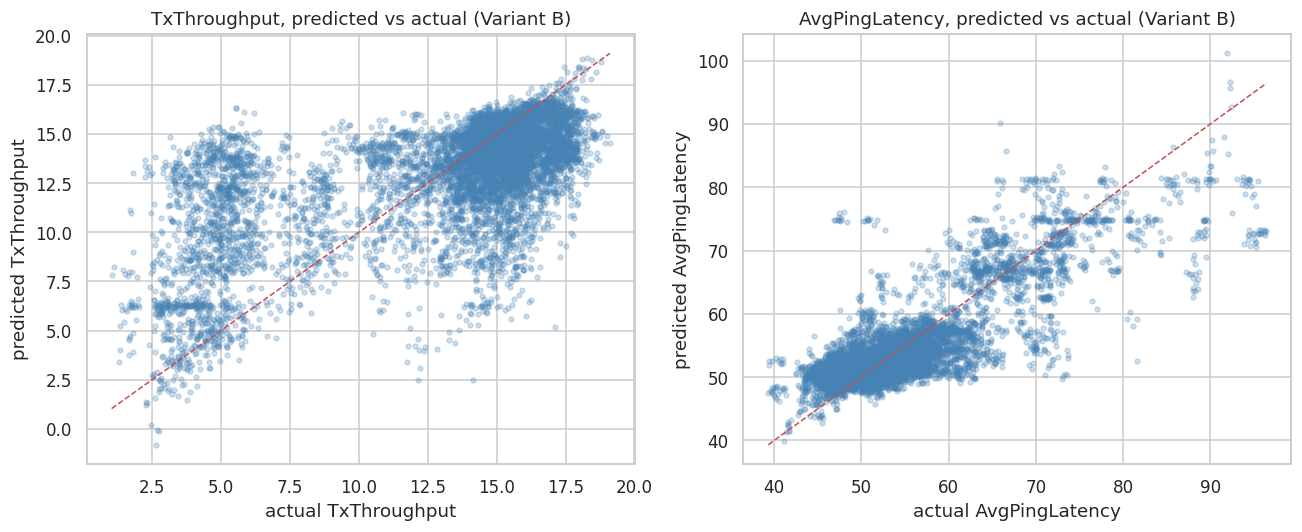

In [32]:
y_pred_b = target_scaler.inverse_transform(model_b.predict(X_test.values, verbose=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, name in enumerate(TARGETS):
    # predicted vs actual
    ax = axes[i]
    ax.scatter(y_test_raw[:, i], y_pred_b[:, i], alpha=0.25, s=10, color="steelblue")
    lo, hi = y_test_raw[:, i].min(), y_test_raw[:, i].max()
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlabel(f"actual {name}")
    ax.set_ylabel(f"predicted {name}")
    ax.set_title(f"{name}, predicted vs actual (Variant B)")

plt.tight_layout(); plt.show()

### 22. Discussion and conclusions

The averaged R² scores for each architecture are the following for Baseline, A, B, C and D respectively: 0.5375, 0.547, 0.5525, 0.545, 0.5425.

From these results we conclude that no architecture hyperparameter tuning leads to noticeable improvements on performance. All of the models perform relatively poorly with an R² a little over 0.5. For reference a model predicitng the average always would get an R² of 0 (since R² measures variance explained, predicting the mean of the targets gives exactly 0).

It is also clear that the task of latency is easier than throughput based on the input features. With respect to throughput the input features (RSSI, link speeds, AP connection, location) are direct physical descriptors of the wireless link, which is the dominant factor behind throughput in lab settings. However, in a real residential network the achieved throughput is also driven by external factors that we do not observe: number of concurrent users, background traffic, interference from neighbour networks, channel congestion, application-level bottlenecks, etc. Including these could potentially improve the prediciton capability of these models. Latency, on the other hand, is dominated by the path to the server and tends to vary in a narrower, more stationary range, which makes it easier to predict on average.

From this it follows that the limiting factor is the dataset. Clearly the relation between features and labels is not trivial, and very abstract, or non-existing. From these features it likely impossible to find patterns to reliably predict the labels. Perhaps adding other features like channel utilisation, number of associated stations, interference level, time of day, or traffic load could better help the models to find abstract patterns and improve on predictions. The fascinating thing about neural networks, and machine learning in general, is that these models can find relationships that we did not know of, that live in higher dimensions. Thus including more features and then removing unwanted ones is always a stable strategy.

In [ ]:
# to save the models 
import os
import joblib

os.makedirs("saved_models", exist_ok=True)

# Keras models, native .keras format
model.save("saved_models/baseline.keras")
model_a.save("saved_models/model_a_deeper.keras")
model_b.save("saved_models/model_b_wider.keras")
model_c.save("saved_models/model_c_no_dropout.keras")
model_d.save("saved_models/model_d_deep_bn.keras")

# Scalers, needed to reproduce predictions in the original units
joblib.dump(feat_scaler, "saved_models/feat_scaler.joblib")
joblib.dump(target_scaler, "saved_models/target_scaler.joblib")

print("Saved:", os.listdir("saved_models"))

In [ ]:
# to reload a model 

#model_b = load_model("saved_models/model_b_wider.keras")
#feat_scaler = joblib.load("saved_models/feat_scaler.joblib")
#target_scaler = joblib.load("saved_models/target_scaler.joblib")